# 03 - Short-Term Modeling

Review the 48-hour half-hourly model, validation metrics, saved model, and final forecasts.

In [6]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

metrics_path = ROOT / "outputs" / "group5" / "metrics" / "validation_metrics.csv"
valid_path = ROOT / "outputs" / "group5" / "metrics" / "validation_predictions_half_hourly.csv"
forecast_path = ROOT / "outputs" / "group5" / "predictions" / "group_5_half_hourly_predict.csv"
model_path = ROOT / "models" / "short_term" / "group5_half_hourly_gradient_boosting.joblib"

print("Run the pipeline first if these files are missing:")
print("EI-climat/bin/python scripts/group5_run_pipeline.py")

Run the pipeline first if these files are missing:
EI-climat/bin/python scripts/group5_run_pipeline.py


In [7]:
metrics = pd.read_csv(metrics_path)
half_metrics = metrics[metrics["frequency"] == "half_hourly"].sort_values(["acorn", "rmse"])
half_metrics

,frequency,model,acorn,rmse,n
17,half_hourly,gradient_boosting,ACORN-E,0.007440,1344
13,half_hourly,ridge,ACORN-E,0.010830,1344
1,half_hourly,previous_day,ACORN-E,0.021247,1344
5,half_hourly,previous_week,ACORN-E,0.025561,1344
9,half_hourly,seasonal_mean,ACORN-E,0.047075,1344
18,half_hourly,gradient_boosting,ACORN-F,0.008218,1344
14,half_hourly,ridge,ACORN-F,0.010307,1344
2,half_hourly,previous_day,ACORN-F,0.023342,1344
6,half_hourly,previous_week,ACORN-F,0.026420,1344
10,half_hourly,seasonal_mean,ACORN-F,0.043403,1344


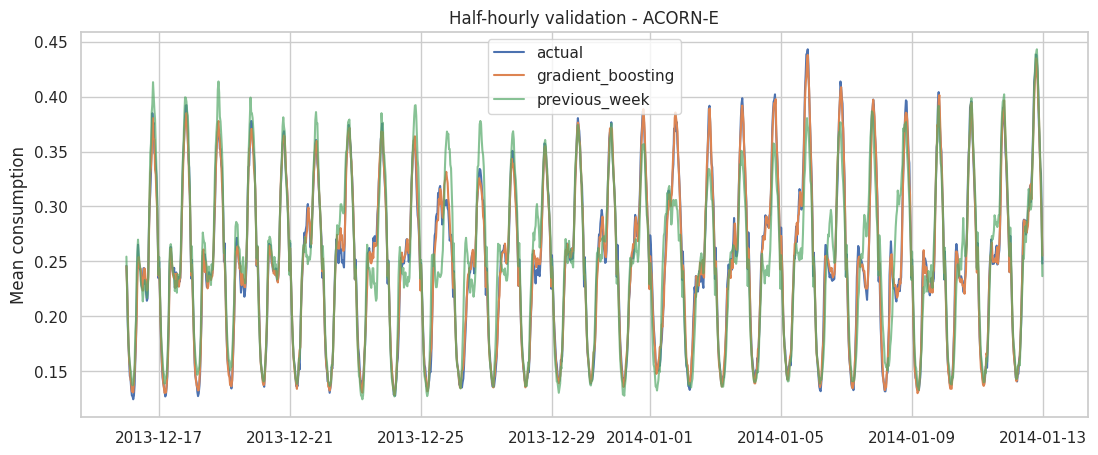

In [8]:
valid = pd.read_csv(valid_path, parse_dates=["timestamp"])
acorn = "ACORN-E"
plot_df = valid[valid["Acorn"] == acorn].copy()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(plot_df["timestamp"], plot_df["actual"], label="actual")
ax.plot(plot_df["timestamp"], plot_df["gradient_boosting"], label="gradient_boosting")
ax.plot(plot_df["timestamp"], plot_df["previous_week"], label="previous_week", alpha=0.7)
ax.set_title(f"Half-hourly validation - {acorn}")
ax.set_ylabel("Mean consumption")
ax.legend()
plt.show()

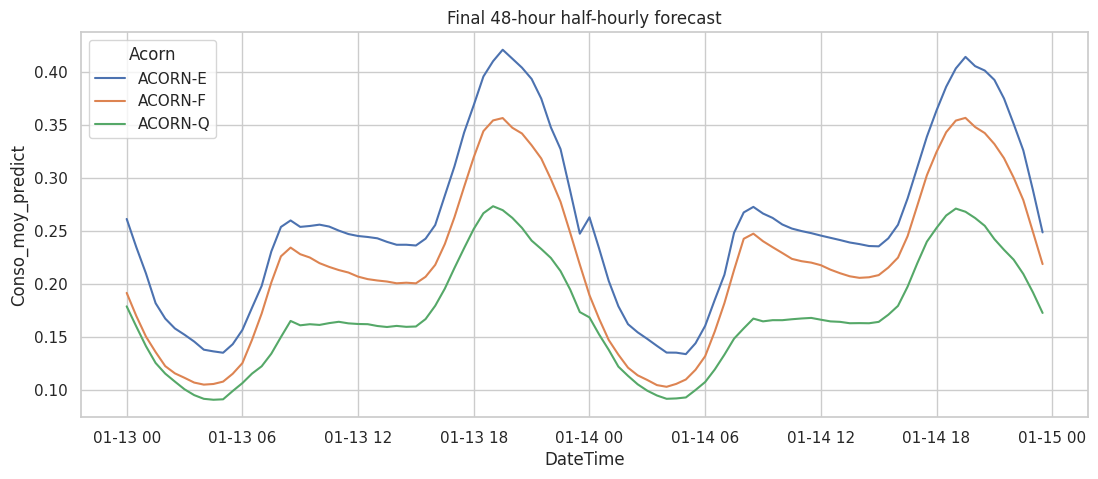

,Acorn,DateTime,Conso_moy_predict
0,ACORN-E,2014-01-13 00:00:00,0.261500
1,ACORN-E,2014-01-13 00:30:00,0.234838
2,ACORN-E,2014-01-13 01:00:00,0.210130
3,ACORN-E,2014-01-13 01:30:00,0.182075
4,ACORN-E,2014-01-13 02:00:00,0.167556


In [9]:
forecast = pd.read_csv(forecast_path, parse_dates=["DateTime"])
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=forecast, x="DateTime", y="Conso_moy_predict", hue="Acorn", ax=ax)
ax.set_title("Final 48-hour half-hourly forecast")
plt.show()

forecast.head()

In [10]:
print("Saved short-term model:", model_path)
print("Exists:", model_path.exists())

Saved short-term model: /home/baunilha/Repositories/ei-climat/models/short_term/group5_half_hourly_gradient_boosting.joblib
Exists: True
